In [20]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [22]:
c, _, _, _, _ = load_and_unify_data('/content/extracted_coordinates_x_b_noVec.csv', '/content/extracted_coordinates_y_b_noVec.csv')

✓ SPP file loaded with 7973 rows.
✓ Kinematic file loaded with 7910 rows.


In [23]:
c

,GPST,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),vx(m/s),vy(m/s),vz(m/s),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2024-02-14 04:19:28,461332.1582,5.634451e+06,2.945941e+06,13.0,3.5287,11.2818,6.9751,0.00394,0.01413,-0.01400,461329.8229,5.634439e+06,2.945930e+06,-2.3353,-11.9833,-11.1453
1,2024-02-14 04:19:29,461332.0927,5.634452e+06,2.945941e+06,13.0,3.5287,11.2825,6.9752,-0.01285,-0.07268,-0.01953,461329.8225,5.634439e+06,2.945930e+06,-2.2702,-12.0702,-11.3839
2,2024-02-14 04:19:30,461332.1570,5.634452e+06,2.945941e+06,13.0,3.5287,11.2832,6.9753,0.01059,0.00316,-0.00138,461329.8234,5.634439e+06,2.945930e+06,-2.3336,-12.1444,-11.2149
3,2024-02-14 04:19:31,461332.1452,5.634451e+06,2.945941e+06,13.0,3.5287,11.2839,6.9755,0.00565,-0.02572,-0.02712,461329.8237,5.634439e+06,2.945930e+06,-2.3215,-11.8067,-11.1306
4,2024-02-14 04:19:32,461332.2278,5.634451e+06,2.945940e+06,13.0,3.5287,11.2846,6.9756,-0.00935,0.04126,0.02129,461329.8229,5.634439e+06,2.945930e+06,-2.4049,-11.5746,-10.9527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7905,2024-02-14 06:32:16,464118.3633,5.632637e+06,2.949008e+06,12.0,6.0019,21.8718,8.2883,0.70386,-1.01379,1.73050,464115.5768,5.632630e+06,2.948996e+06,-2.7865,-6.2407,-11.6303
7906,2024-02-14 06:32:17,464119.3652,5.632636e+06,2.949009e+06,11.0,10.7919,30.4155,11.5919,1.33650,-1.13444,1.68668,464120.9077,5.632624e+06,2.948997e+06,1.5425,-12.2113,-12.3875
7907,2024-02-14 06:32:18,464120.3386,5.632635e+06,2.949011e+06,11.0,10.7929,30.4123,11.5914,1.08636,0.16246,1.98146,464112.4989,5.632624e+06,2.949003e+06,-7.8397,-11.4952,-8.3335
7908,2024-02-14 06:32:19,464122.0149,5.632634e+06,2.949013e+06,11.0,10.7938,30.4091,11.5910,1.99354,-1.73132,1.09637,464113.8278,5.632623e+06,2.949004e+06,-8.1871,-11.3048,-8.2500


In [24]:
c[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,7910.000000,7910.000000,7910.000000
mean,-1.544412,-11.607630,-10.268504
std,2.183539,8.741975,3.148556
min,-17.801200,-92.033700,-47.289900
25%,-2.646650,-13.932600,-11.308500
50%,-1.675250,-10.202300,-9.622200
75%,-0.595925,-7.123900,-8.535350
max,36.715500,27.580000,2.672600


In [25]:
dx = np.array(c['diff_x'])
dy = np.array(c['diff_y'])
dz = np.array(c['diff_z'])

In [26]:
np.mean(np.sqrt((dx**2) + (dy**2) + (dz**2)))

np.float64(16.257782583959923)

#NN Ensamble

✓ SPP file loaded with 7973 rows.
✓ Kinematic file loaded with 7910 rows.

TRAINING NEURAL NETWORK MODEL
Epoch 1/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1.3268 - rmse: 1.1455 - val_loss: 1.0851 - val_rmse: 1.0417
Epoch 2/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9432 - rmse: 0.9706 - val_loss: 1.0080 - val_rmse: 1.0040
Epoch 3/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8635 - rmse: 0.9282 - val_loss: 0.9368 - val_rmse: 0.9679
Epoch 4/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7939 - rmse: 0.8905 - val_loss: 0.9641 - val_rmse: 0.9819
Epoch 5/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7438 - rmse: 0.8615 - val_loss: 1.0288 - val_rmse: 1.0143
Epoch 6/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7686 - rmse: 0.8758 - val_loss: 1.0061 - val_rmse: 1.0031
Epoch 7/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7148 - rmse: 0.8453 - val_loss: 0.9299 - val_rmse: 0.9643
Epoch 8/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

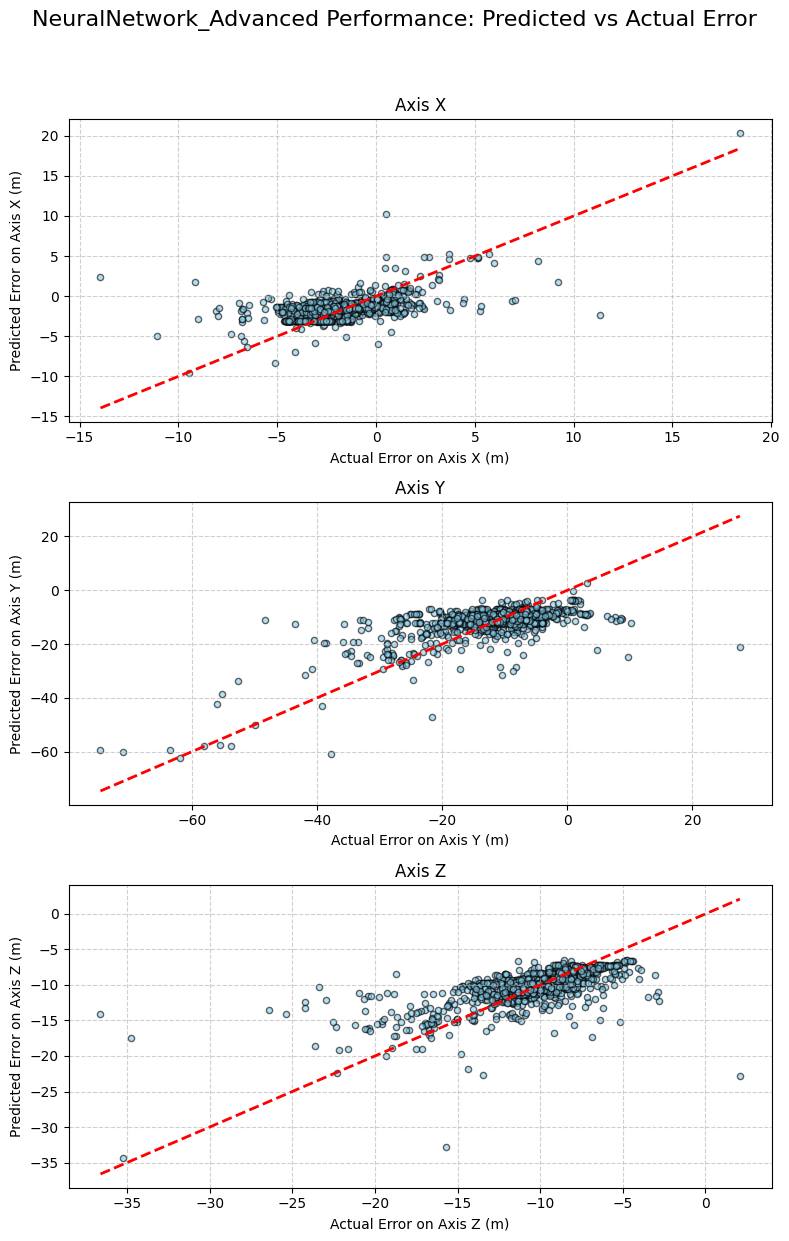

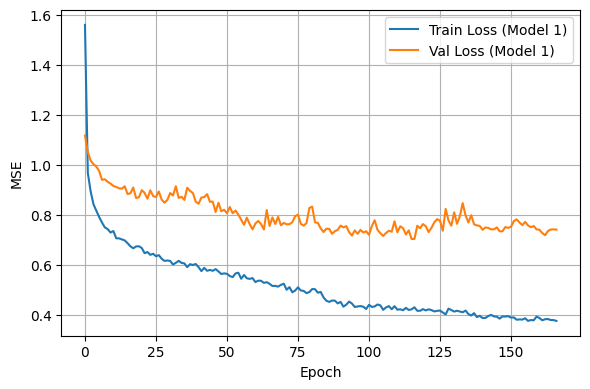


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 16.0840 m
Mean 3D Error (Corrected): 2.1944 m

Improvement: 13.8896 m (86.36%)

✓ Best model, scaler, and feature list saved successfully!

✓ Analysis complete!


In [34]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)', 'vx(m/s)', 'vy(m/s)', 'vz(m/s)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'


# --- 2. MODEL TRAINING AND EVALUATION ---



def train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=False):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Define NN builder ---
    def build_model(seed):
        tf.keras.utils.set_random_seed(seed)
        inputs = layers.Input(shape=(X_train_scaled.shape[1],))
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x1 = layers.Dense(64, activation='relu')(x)
        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Dropout(0.3)(x1)

        x = layers.Concatenate()([x, x1])
        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(3)(x)
        model = models.Model(inputs, outputs)

        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
        return model

    # --- Train multiple NNs ---
    models_list = []
    histories = []
    for i in range(n_networks):
        print(f"\n{'='*80}\nTraining Neural Net #{i+1}/{n_networks}\n{'='*80}")
        model = build_model(seed=42+i)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, verbose=1, min_lr=1e-6)

        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_split=0.2,
            epochs=500,
            batch_size=32,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        models_list.append(model)
        histories.append(history)

    # --- Average ensemble predictions ---
    preds_scaled = np.zeros_like(y_test_scaled)
    for model in models_list:
        preds_scaled += model.predict(X_test_scaled)
    preds_scaled /= n_networks

    y_pred = y_scaler.inverse_transform(preds_scaled)
    y_test_vals = y_test.values

    # --- Optional: Add tree model (hybrid ensemble) ---
    if add_tree:
        try:
            from xgboost import XGBRegressor
            print("\nTraining hybrid XGBoost regressor on NN residuals...")
            residuals = y_test_vals - y_pred
            tree_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
            tree_model.fit(X_test_scaled, residuals)
            tree_pred = tree_model.predict(X_test_scaled)
            y_pred += tree_pred
        except ImportError:
            print("XGBoost not installed — skipping hybrid stage.")

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: ENSEMBLE MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot learning curves for first model ---
    plt.figure(figsize=(6,4))
    plt.plot(histories[0].history['loss'], label='Train Loss (Model 1)')
    plt.plot(histories[0].history['val_loss'], label='Val Loss (Model 1)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return models_list, x_scaler, y_scaler, X_test, y_pred

# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")


# --- 4. VISUALIZATION ---

def plot_results(y_test, y_pred, model_name):
    """Generates and saves performance plots."""
    fig, axes = plt.subplots(3, 1, figsize=(8, 12), tight_layout=True)
    fig.suptitle(f'{model_name} Performance: Predicted vs Actual Error', fontsize=16, y=1.03)
    for i, label in enumerate(['X', 'Y', 'Z']):
        ax = axes[i]
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=20, edgecolors='k', c='skyblue')
        ax.plot([y_test[:, i].min(), y_test[:, i].max()],
                [y_test[:, i].min(), y_test[:, i].max()], 'r--', lw=2)
        ax.set_xlabel(f'Actual Error on Axis {label} (m)')
        ax.set_ylabel(f'Predicted Error on Axis {label} (m)')
        ax.set_title(f'Axis {label}')
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('model_performance_xyz.png', dpi=300)
    print("\n✓ Performance plots saved as 'model_performance_xyz.png'")


# --- 5. MAIN EXECUTION ---

def main():
    spp_filepath = '/content/extracted_coordinates_x_b_noVec.csv'
    kinematic_filepath = '/content/extracted_coordinates_y_b_noVec.csv'

    unified_df, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
    if unified_df is None:
        return

    best_model, x_scaler, y_scaler, X_test, y_pred = train_and_evaluate(unified_df, feature_cols)
    test_df = unified_df.loc[X_test.index]

    best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=True)


    calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))

    joblib.dump(best_model, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")


if __name__ == "__main__":
    main()


above is the data without iono correction

✓ SPP file loaded with 7962 rows.
✓ Kinematic file loaded with 7910 rows.

TRAINING NEURAL NETWORK MODEL
Epoch 1/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 1.2515 - rmse: 1.1120 - val_loss: 1.0237 - val_rmse: 1.0118
Epoch 2/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7614 - rmse: 0.8717 - val_loss: 0.9305 - val_rmse: 0.9646
Epoch 3/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6972 - rmse: 0.8339 - val_loss: 0.9070 - val_rmse: 0.9524
Epoch 4/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6577 - rmse: 0.8101 - val_loss: 0.9091 - val_rmse: 0.9534
Epoch 5/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6257 - rmse: 0.7902 - val_loss: 0.9403 - val_rmse: 0.9697
Epoch 6/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6008 - rmse: 0.7744 - val_loss: 0.8996 - val_rmse: 0.9484
Epoch 7/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5943 - rmse: 0.7700 - val_loss: 0.9035 - val_rmse: 0.9505
Epoch 8/500
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms

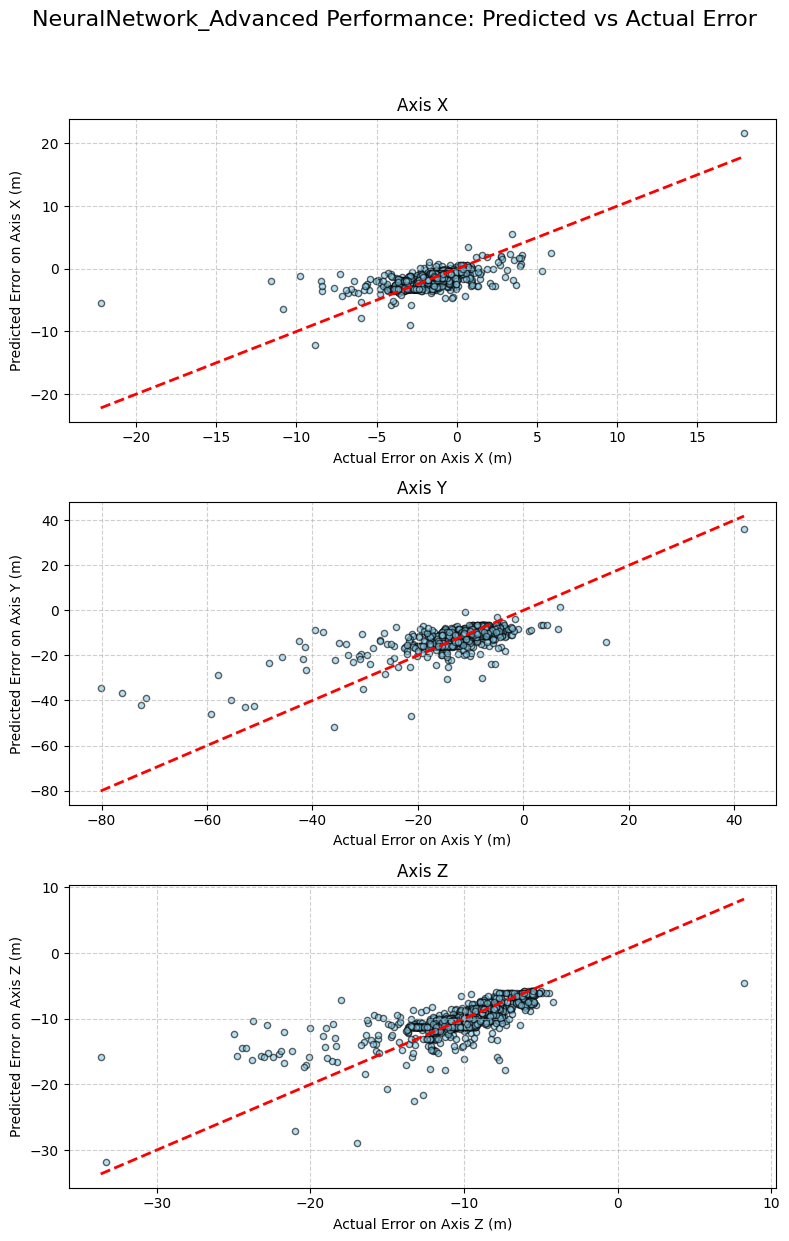

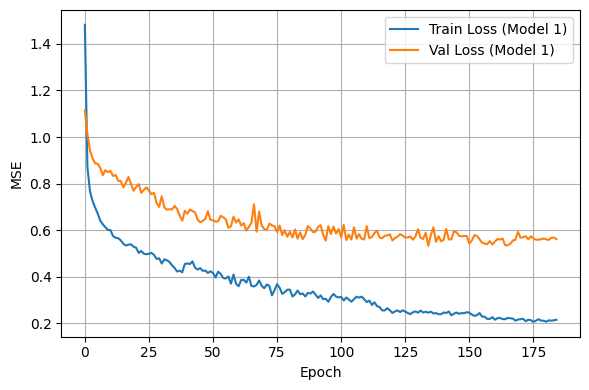


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 15.9597 m
Mean 3D Error (Corrected): 1.2024 m

Improvement: 14.7574 m (92.47%)

✓ Best model, scaler, and feature list saved successfully!

✓ Analysis complete!


In [36]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)', 'vx(m/s)', 'vy(m/s)', 'vz(m/s)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'


# --- 2. MODEL TRAINING AND EVALUATION ---



def train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=False):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Define NN builder ---
    def build_model(seed):
        tf.keras.utils.set_random_seed(seed)
        inputs = layers.Input(shape=(X_train_scaled.shape[1],))
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x1 = layers.Dense(64, activation='relu')(x)
        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Dropout(0.3)(x1)

        x = layers.Concatenate()([x, x1])
        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(3)(x)
        model = models.Model(inputs, outputs)

        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
        return model

    # --- Train multiple NNs ---
    models_list = []
    histories = []
    for i in range(n_networks):
        print(f"\n{'='*80}\nTraining Neural Net #{i+1}/{n_networks}\n{'='*80}")
        model = build_model(seed=42+i)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, verbose=1, min_lr=1e-6)

        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_split=0.2,
            epochs=500,
            batch_size=32,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        models_list.append(model)
        histories.append(history)

    # --- Average ensemble predictions ---
    preds_scaled = np.zeros_like(y_test_scaled)
    for model in models_list:
        preds_scaled += model.predict(X_test_scaled)
    preds_scaled /= n_networks

    y_pred = y_scaler.inverse_transform(preds_scaled)
    y_test_vals = y_test.values

    # --- Optional: Add tree model (hybrid ensemble) ---
    if add_tree:
        try:
            from xgboost import XGBRegressor
            print("\nTraining hybrid XGBoost regressor on NN residuals...")
            residuals = y_test_vals - y_pred
            tree_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
            tree_model.fit(X_test_scaled, residuals)
            tree_pred = tree_model.predict(X_test_scaled)
            y_pred += tree_pred
        except ImportError:
            print("XGBoost not installed — skipping hybrid stage.")

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: ENSEMBLE MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot learning curves for first model ---
    plt.figure(figsize=(6,4))
    plt.plot(histories[0].history['loss'], label='Train Loss (Model 1)')
    plt.plot(histories[0].history['val_loss'], label='Val Loss (Model 1)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return models_list, x_scaler, y_scaler, X_test, y_pred

# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")


# --- 4. VISUALIZATION ---

def plot_results(y_test, y_pred, model_name):
    """Generates and saves performance plots."""
    fig, axes = plt.subplots(3, 1, figsize=(8, 12), tight_layout=True)
    fig.suptitle(f'{model_name} Performance: Predicted vs Actual Error', fontsize=16, y=1.03)
    for i, label in enumerate(['X', 'Y', 'Z']):
        ax = axes[i]
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=20, edgecolors='k', c='skyblue')
        ax.plot([y_test[:, i].min(), y_test[:, i].max()],
                [y_test[:, i].min(), y_test[:, i].max()], 'r--', lw=2)
        ax.set_xlabel(f'Actual Error on Axis {label} (m)')
        ax.set_ylabel(f'Predicted Error on Axis {label} (m)')
        ax.set_title(f'Axis {label}')
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('model_performance_xyz.png', dpi=300)
    print("\n✓ Performance plots saved as 'model_performance_xyz.png'")


# --- 5. MAIN EXECUTION ---

def main():
    spp_filepath = '/content/extracted_coordinates_x_b_IONO.csv'
    kinematic_filepath = '/content/extracted_coordinates_y_b_IONO.csv'

    unified_df, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
    if unified_df is None:
        return

    best_model, x_scaler, y_scaler, X_test, y_pred = train_and_evaluate(unified_df, feature_cols)
    test_df = unified_df.loc[X_test.index]

    best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols, n_networks=3, add_tree=True)


    calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))

    joblib.dump(best_model, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")


if __name__ == "__main__":
    main()


above is the data with iono correction